## ファイルの前処理

In [4]:
import os, requests
from Bio import PDB
from pdbfixer import PDBFixer
from openmm.app import PDBFile

In [5]:
base_dir = "/home/shaeo/cadd_training/20250926_OpenMM"

In [6]:
# ファイルのダウンロード（4ZJ8: OX1）
pdb_id = "4ZJC"
pdb_id = pdb_id.lower()
url = f"https://biomembhub.org/shared/opm-assets/pdb/{pdb_id}.pdb"
os.makedirs(base_dir + "/data", exist_ok=True)
out_file = base_dir + f"/data/{pdb_id}_opm.pdb"

response = requests.get(url)
if response.status_code == 200:
    with open(out_file, "wb") as f:
        f.write(response.content)
else:
    print(f"Failed to fetch {pdb_id} from OPM (status {response.status_code})")

In [7]:
# リガンドとレセプターの分割
protein_file = base_dir + f"/data/receptor_{pdb_id}.pdb"
ligand_file = base_dir + f"/data/ligand_{pdb_id}.pdb"
ligand_resname = "4OT"

parser = PDB.PDBParser(QUIET=True)
structure = parser.get_structure("complex", out_file)
io = PDB.PDBIO()

# レセプターを抽出
class ProteinSelect(PDB.Select):
    def accept_residue(self, residue):
        if not PDB.is_aa(residue, standard=True): # アミノ酸かどうか
            return False
        res_id = residue.id[1]
        if 1001 <= res_id <= 1196: # 残基番号を取得 (id[1] が residue number)
            return False  # この範囲は除外
        return True
io.set_structure(structure)
io.save(protein_file, ProteinSelect())

# リガンドを抽出
class LigandSelect(PDB.Select):
    def accept_residue(self, residue):
        return residue.get_resname().strip() == ligand_resname
io.set_structure(structure)
io.save(ligand_file, LigandSelect())

In [8]:
# リガンドのファイル形式を変換
ligand_sdf = base_dir + f"/data/ligand_{pdb_id}.sdf"
!obabel $ligand_file -O $ligand_sdf -p 7.4

1 molecule converted


In [9]:
# PDBfixer
protein_file_fixed = base_dir + f"/data/receptor_{pdb_id}-fixed.pdb"

fixer = PDBFixer(filename=protein_file)
fixer.findNonstandardResidues()
fixer.replaceNonstandardResidues()
fixer.removeHeterogens(keepWater=False)
fixer.findMissingResidues()
fixer.findMissingAtoms()
fixer.addMissingAtoms()
fixer.addMissingHydrogens(pH=7.4)

with open(protein_file_fixed, "w") as f:
    PDBFile.writeFile(fixer.topology, fixer.positions, f, keepIds=True)

## 複合体の準備

In [10]:
import numpy as np
from rdkit import Chem
import mdtraj as md
import openmm as mm
import openmm.app as app
from openmm import unit
from openff.toolkit.topology import Molecule
from openmmforcefields.generators import GAFFTemplateGenerator

In [11]:
# リガンドの前処理
ligname = "LIG"
supplier = Chem.SDMolSupplier(ligand_sdf, removeHs=False)
rdkit_mol = supplier[0]

# OpenFFのオブジェクトに変換
off_mol = Molecule.from_rdkit(rdkit_mol)    
off_mol.name = ligname  # リガンドの名前を指定

# 原子番号の指定
element_counter_dict = {}
for off_atom, rdkit_atom in zip(off_mol.atoms, rdkit_mol.GetAtoms()):
    element = rdkit_atom.GetSymbol()
    if element in element_counter_dict.keys():
        element_counter_dict[element] += 1
    else:
        element_counter_dict[element] = 1
    off_atom.name = element + str(element_counter_dict[element])

# OpenMMのオブジェクトに変換
off_mol_topology = off_mol.to_topology()
mol_topology = off_mol_topology.to_openmm()
mol_positions = off_mol.conformers[0]
mol_positions = mol_positions.to("nanometers")  # 単位を変換：Å → nm
omm_mol = app.Modeller(mol_topology, mol_positions)

In [12]:
# rガンド-タンパク質複合体の形成
md_protein_topology = md.Topology.from_openmm(fixer.topology)  # PDBfixerのオブジェクトを利用
md_ligand_topology = md.Topology.from_openmm(omm_mol.topology)
md_complex_topology = md_protein_topology.join(md_ligand_topology)
complex_topology = md_complex_topology.to_openmm()  # OpenMMのオブジェクトに変換

# 座標の更新
total_atoms = len(fixer.positions) + len(omm_mol.positions)
complex_positions = unit.Quantity(np.zeros([total_atoms, 3]), unit=unit.nanometers) # OpenMMで利用される配列
complex_positions[: len(fixer.positions)] = fixer.positions # タンパク質の座標を追加
complex_positions[len(fixer.positions) :] = omm_mol.positions   # リガンドの座標を追加

/home/shaeo/miniconda3/envs/openmm/lib/python3.10/site-packages/openmm/unit/quantity.py:752: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  self._value[key] = value / self.unit


In [13]:
# 力場の設定
protein_ff="amber14-all.xml"    # タンパク質の力場（膜脂質の力場を含む）
solvent_ff="amber14/tip3pfb.xml"    # 水の力場
forcefield = app.ForceField(protein_ff, solvent_ff) 
gaff = GAFFTemplateGenerator(
    molecules=Molecule.from_rdkit(rdkit_mol, allow_undefined_stereo=True) # リガンドの力場/電荷を設定
)
forcefield.registerTemplateGenerator(gaff.generator)

In [14]:
# 複合体に水/イオン/膜脂質を追加
modeller = app.Modeller(complex_topology, complex_positions)
modeller.addMembrane(
    forcefield,
    lipidType="POPC",
    membraneCenterZ=0.0*unit.nanometer,  # 膜中心の Z 位置
    minimumPadding=1.0*unit.nanometer,    # タンパク質等との余裕 (10Å)
    positiveIon="Na+",
    negativeIon="Cl-",              
    ionicStrength=0.15*unit.molar
)

In [15]:
# PDBファイルとして保存
complex_file = base_dir + f"/data/complex_{pdb_id}.pdb"
with open(complex_file, "w") as f:
    PDBFile.writeFile(modeller.topology, modeller.positions, f)

## MDシミュレーション

In [18]:
result_dir = base_dir + "/result"
os.makedirs(result_dir, exist_ok=True)

In [21]:
# simulationオブジェクトを作成

# システム
system = forcefield.createSystem(
    modeller.topology,
    nonbondedMethod=app.PME,
    nonbondedCutoff=1.0*unit.nanometer,
    constraints='HBonds'
)
if not system.getDefaultPeriodicBoxVectors():
    system.setDefaultPeriodicBoxVectors(*modeller.topology.getPeriodicBoxVectors())

# バロスタット
barostat = mm.MonteCarloMembraneBarostat(
    1*unit.bar,                      # 圧力
    0*unit.bar*unit.nanometer,       # 表面張力（通常は0）
    300*unit.kelvin,                 # 温度
    mm.MonteCarloMembraneBarostat.XYIsotropic,
    mm.MonteCarloMembraneBarostat.ZFree,
    25                                # 頻度
)
system.addForce(barostat)

# インテグレーター
integrator = mm.LangevinIntegrator(
    10*unit.kelvin,
    1/unit.picosecond,
    0.002*unit.picoseconds
)

# プラットフォーム
platform = mm.Platform.getPlatformByName('CUDA')  # または 'OpenCL', 'CPU'
properties = {'Precision': 'mixed'} # GPUの計算精度

# トポロジーと座標の取得
topology = modeller.getTopology()
positions = modeller.getPositions()

simulation = app.Simulation(topology, system, integrator, platform, properties)
simulation.context.setPositions(positions)

### 1.エネルギー最適化

In [64]:
em_path = result_dir + '/1_minimization'
os.makedirs(em_path, exist_ok=True)

In [65]:
state_path_em = em_path + "/state.xml"
structure_path_em = em_path + "/structure.pdb"

In [30]:
# 実行
simulation.minimizeEnergy()

In [31]:
# 保存
state_em = simulation.context.getState(
    getPositions=True, 
    getVelocities=True,
    getEnergy=True,
    getForces=True,
    getParameters=True,
    enforcePeriodicBox=True
)
with open(state_path_em, "w") as f:
    f.write(mm.XmlSerializer.serialize(state_em))
positions_em = simulation.context.getState(getPositions=True).getPositions()
with open(structure_path_em, "w") as f:
    PDBFile.writeFile(simulation.topology, positions_em, f)

### 2.等温緩和

In [66]:
qd_path = result_dir + '/2_quenched_dynamics'
os.makedirs(qd_path, exist_ok=True)

In [67]:
state_path_qd = qd_path + "/state.xml"
structure_path_qd = qd_path + "/structure.pdb"
dcd_path_qd = qd_path + "/traj.dcd"
log_path_qd = qd_path + "/log.log"

In [34]:
# 設定
simulation.currentStep = 0
simulation.reporters = []
simulation.reporters.append(app.DCDReporter(dcd_path_qd, 2))
simulation.reporters.append(
    app.StateDataReporter(
        log_path_qd, 2, totalSteps=10, step=True, speed=True, progress=True, potentialEnergy=True, temperature=True
    )
)
simulation.context.setState(state_em)

In [35]:
# 実行
simulation.step(10)

In [36]:
# 保存
state_qd = simulation.context.getState(
    getPositions=True,
    getVelocities=True,
    getEnergy=True,
    getForces=True,
    getParameters=True,
    enforcePeriodicBox=True
)
with open(state_path_qd, "w") as f:
    f.write(mm.XmlSerializer.serialize(state_qd))
positions_qd = simulation.context.getState(getPositions=True).getPositions()
with open(structure_path_qd, "w") as f:
    PDBFile.writeFile(simulation.topology, positions_qd, f)

### 3.昇温

In [68]:
ht_path = result_dir + '/3_heating'
os.makedirs(ht_path, exist_ok=True)

In [69]:
state_path_ht = ht_path + "/state.xml"
structure_path_ht = ht_path + "/structure.pdb"
dcd_path_ht = ht_path + "/traj.dcd"
log_path_ht = ht_path + "/log.log"

In [40]:
# 設定
n_steps = 250000  # 2fs * 250,000 = 500,000fs ← 500ps ← 0.5ns
simulation.context.setState(state_qd)
simulation.currentStep = 0
simulation.reporters = []
simulation.reporters.append(app.DCDReporter(dcd_path_ht, 5000))
simulation.reporters.append(
    app.StateDataReporter(
        log_path_ht, 5000, totalSteps=n_steps, step=True, speed=True, progress=True, potentialEnergy=True, temperature=True
    )
)

In [41]:
# 拘束条件: 脂質、タンパク主鎖、リガンド
restraint = mm.CustomExternalForce("k*periodicdistance(x, y, z, x0, y0, z0)^2")
res_idx = system.addForce(restraint)
restraint.addGlobalParameter("k", 1000.0*unit.kilojoules_per_mole/unit.nanometer)
restraint.addPerParticleParameter("x0")
restraint.addPerParticleParameter("y0")
restraint.addPerParticleParameter("z0")
lipid_atoms = [atom for atom in topology.atoms() if atom.residue.name=="POP"]
for atom in lipid_atoms:
    restraint.addParticle(atom.index, positions[atom.index])
protein_atoms = [atom for atom in topology.atoms() if atom.name in ["CA", "N", "C", "O"]]
for i in protein_atoms:
   restraint.addParticle(atom.index, positions[atom.index])
ligand_atoms = [atom for atom in topology.atoms() if atom.residue.name=="LIG"]
for i in protein_atoms:
   restraint.addParticle(atom.index, positions[atom.index])

In [42]:
# 実行
list_temp = [100, 150, 200, 250, 300]
list_step = [50000, 50000, 50000, 50000, 50000]
for temp, step in zip(list_temp, list_step):
    integrator.setTemperature(temp*unit.kelvin)
    barostat.setDefaultTemperature(temp*unit.kelvin)
    simulation.step(step)

In [43]:
# 保存
state_ht = simulation.context.getState(
    getPositions=True,
    getVelocities=True,
    getEnergy=True,
    getForces=True,
    getParameters=True,
    enforcePeriodicBox=True
)
with open(state_path_ht, "w") as f:
    f.write(mm.XmlSerializer.serialize(state_ht))
positions_ht = simulation.context.getState(getPositions=True).getPositions()
with open(structure_path_ht, "w") as f:
    PDBFile.writeFile(simulation.topology, positions_ht, f)

### 4.平衡化

In [70]:
eq_path = result_dir + '/4_equibaration'
os.makedirs(eq_path, exist_ok=True)

In [71]:
state_path_eq = eq_path + "/state.xml"
structure_path_eq = eq_path + "/structure.pdb"
dcd_path_eq = eq_path + "/traj.dcd"
log_path_eq = eq_path + "/log.log"

In [49]:
# 設定
n_steps = 250000  # 2fs * 250,000 = 500,000fs ← 500ps ← 0.5ns
simulation.context.setState(state_ht)
simulation.currentStep = 0
simulation.reporters = []
simulation.reporters.append(app.DCDReporter(dcd_path_eq, 5000))
simulation.reporters.append(
    app.StateDataReporter(
        log_path_eq, 5000, totalSteps=n_steps, step=True, speed=True, progress=True, potentialEnergy=True, temperature=True
    )
)

In [50]:
# 実行
list_restrain = [1000.0, 300.0, 100.0, 30.0, 0.0]
list_step = [5000, 40000, 40000, 40000, 125000]
for k, step in zip(list_restrain, list_step):
    restraint.setGlobalParameterDefaultValue(0, k*unit.kilojoules_per_mole/unit.nanometer)  
    simulation.step(step)

In [51]:
# 保存
state_eq = simulation.context.getState(
    getPositions=True,
    getVelocities=True,
    getEnergy=True,
    getForces=True,
    getParameters=True,
    enforcePeriodicBox=True
)
with open(state_path_eq, "w") as f:
    f.write(mm.XmlSerializer.serialize(state_eq))
positions_eq = simulation.context.getState(getPositions=True).getPositions()
with open(structure_path_eq, "w") as f:
    PDBFile.writeFile(simulation.topology, positions_eq, f)

### 5.生産

In [72]:
md_path = result_dir + '/5_production'
os.makedirs(md_path, exist_ok=True)

In [73]:
state_path_md = md_path + "/state.xml"
structure_path_md = md_path + "/structure.pdb"
dcd_path_md = md_path + "/traj.dcd"
log_path_md = md_path + "/log.log"
checkpoint_path = md_path + "/checkpoint.chk"

In [54]:
# 設定
n_steps = 500000  # 2fs * 500,000 = 1,000,000fs ← 1000ps ← 1.0ns
simulation.context.setState(state_eq)
simulation.currentStep = 0
simulation.reporters = []
simulation.reporters.append(app.DCDReporter(dcd_path_md, 5000))
simulation.reporters.append(
    app.StateDataReporter(
        log_path_md, 5000, totalSteps=n_steps, step=True, speed=True, progress=True, potentialEnergy=True, temperature=True
    )
)

In [55]:
# 実行
simulation.step(n_steps)

In [59]:
# 保存
state_md = simulation.context.getState(
    getPositions=True,
    getVelocities=True,
    getEnergy=True,
    getForces=True,
    getParameters=True,
    enforcePeriodicBox=True
)
with open(state_path_md, "w") as f:
    f.write(mm.XmlSerializer.serialize(state_md))
positions_md = simulation.context.getState(getPositions=True).getPositions()
with open(structure_path_md, "w") as f:
    PDBFile.writeFile(simulation.topology, positions_md, f)
with open(checkpoint_path, "wb") as f:
    f.write(simulation.context.createCheckpoint())

Exception ignored in: <function DCDReporter.__del__ at 0x756bd4d6f910>
Traceback (most recent call last):
  File "/home/shaeo/miniconda3/envs/openmm/lib/python3.10/site-packages/openmm/app/dcdreporter.py", line 121, in __del__
    self._out.close()
AttributeError: 'DCDReporter' object has no attribute '_out'


### 6.トラジェクトリの後処理

In [74]:
fixed_path_ht = eq_path + "/traj_pc.dcd"
fixed_path_eq = ht_path + "/traj_pc.dcd"
fixed_path_md = md_path + "/traj_pc.dcd"

In [75]:
dict_path_dcd = {
    dcd_path_ht:fixed_path_ht,
    dcd_path_eq:fixed_path_eq,
    dcd_path_md:fixed_path_md,
}

In [76]:
# PBC補正
for dcd_path, fixed_dcd_path in dict_path_dcd.items():
    traj = md.load(dcd_path, top=structure_path_em)
    traj_whole = traj.make_molecules_whole()    # 分子を “ちぎれない” 形に直す（make whole）
    prot = traj_whole.topology.select("protein")    # タンパクを基準にセンタリング＆ボックス内にラップ
    traj_centered = traj_whole.center_coordinates()
    traj_wrapped = traj_centered.image_molecules()  # 近接イメージに押し戻す
    traj_fit = traj_wrapped.superpose(traj_wrapped, frame=0, atom_indices=prot)     # 剛体合わせ（平行移動・回転除去）してRMSD等が滑らかに
    traj_fit.save_dcd(fixed_dcd_path)

## 解析

### MM/GBSA、MM/PBSA

In [290]:
from openmm.app.pdbfile import PDBFile
import parmed as pmd
from parmed.tools.actions import changeRadii
import pandas as pd

In [78]:
complex_prmtop_path = base_dir + "/data/complex.prmtop"
complex_inpcrd_path = base_dir + "/data/complex.inpcrd"
receptor_prmtop_path = base_dir + "/data/receptor.prmtop"
receptor_inpcrd_path = base_dir + "/data/receptor.inpcrd"
ligand_prmtop_path = base_dir + "/data/ligand.prmtop"
ligand_inpcrd_path = base_dir + "/data/ligand.inpcrd"
dcd_mm_path = base_dir + "/result/md_traj_for_mm.dcd"

In [111]:
# PBCを取得
with open(state_path_md, 'r') as f:
    box = {}
    while True:
        line = f.readline()
        if not line: break

        if line.split()[0] == "<A":
            size = line.split()[1].strip('x="')
            box['A'] = float(size)
        elif line.split()[0] == "<B":
            size = line.split()[2].strip('y="')
            box['B'] = float(size)
        elif line.split()[0] == "<C":
            size = line.split()[3].strip('z="').strip('"/>')
            box['C'] = float(size)
        else:
            pass
vectors = [
    mm.Vec3(box["A"], 0.0, 0.0),
    mm.Vec3(0.0, box["B"], 0.0),
    mm.Vec3(0.0, 0.0, box["C"]),
] * unit.nanometer

In [112]:
# sytemの作成
pdb = PDBFile(complex_file)
modeller = app.Modeller(pdb.topology, pdb.positions)
modeller.deleteWater()  # 水分子を削除
to_delete = [res for res in modeller.topology.residues()
             if res.name in ["NA", "CL", "POP"]]
modeller.delete(to_delete)  # 特定の残基を削除
modeller.topology.setPeriodicBoxVectors(vectors)
topology, positions = modeller.topology, modeller.positions # PBC設定

forcefield = app.ForceField(protein_ff, solvent_ff) 
gaff = GAFFTemplateGenerator(
    molecules=Molecule.from_rdkit(rdkit_mol, allow_undefined_stereo=True) # リガンドの力場/電荷を設定
)
forcefield.registerTemplateGenerator(gaff.generator)
export_system = forcefield.createSystem(
    topology,
    nonbondedMethod=app.PME,
    nonbondedCutoff=1.0*unit.nanometer,
    constraints="HBonds"
)

In [113]:
# ParmEd 変換
parm = pmd.openmm.load_topology(topology, export_system, positions)
parm.box = None
changeRadii(parm, "mbondi2").execute()

# 複合体を保存
parm.save(complex_prmtop_path, overwrite=True)
parm.save(complex_inpcrd_path, overwrite=True)

# 受容体のみを選択
parm_receptor = parm["(:1-307)"]    # result/em_structure.pdb
parm_receptor.save(receptor_prmtop_path, overwrite=True)
parm_receptor.save(receptor_inpcrd_path, overwrite=True)

# リガンドのみを選択（例: 残基名 LIG）
parm_ligand = parm["(:UNK)"]
parm_ligand.save(ligand_prmtop_path, overwrite=True)
parm_ligand.save(ligand_inpcrd_path, overwrite=True)

In [114]:
traj = md.load_dcd(fixed_path_md, top=structure_path_em)
# タンパク + リガンドのみ残す
prot_lig = traj.atom_slice(traj.topology.select("protein or resname UNK"))
prot_lig.save_dcd(dcd_mm_path)

#### MM/GBSA

In [291]:
mmgbsa_in_path = base_dir + "/result/mmgbsa.in"
mmgbsa_result_path = base_dir + "/result/mmgbsa.dat"
mmgbsa_csv_path = base_dir + "/result/mmgbsa.csv"

In [116]:
mmgbsa_in = '''
&general
   startframe=1, 
   endframe=1000000,
   interval=1,
   keep_files=0, 
   verbose=1,
/
&gb
   igb=5, 
   saltcon=0.150,
/
'''
with open(mmgbsa_in_path, "w") as f:
    f.write(mmgbsa_in)

In [117]:
!MMPBSA.py -O -i $mmgbsa_in_path -o $mmgbsa_result_path \
  -cp $complex_prmtop_path \
  -rp $receptor_prmtop_path \
  -lp $ligand_prmtop_path \
  -y $dcd_mm_path

Loading and checking parameter files for compatibility...
cpptraj found! Using /home/shaeo/miniconda3/envs/openmm/bin/cpptraj
mmpbsa_py_energy found! Using /home/shaeo/miniconda3/envs/openmm/bin/mmpbsa_py_energy
Preparing trajectories for simulation...
100 frames were processed by cpptraj for use in calculation.

Running calculations on normal system...

Beginning GB calculations with /home/shaeo/miniconda3/envs/openmm/bin/mmpbsa_py_energy
  calculating complex contribution...
  calculating receptor contribution...
  calculating ligand contribution...

Timing:
Total setup time:                           0.007 min.
Creating trajectories with cpptraj:         0.012 min.
Total calculation time:                     2.823 min.

Total GB calculation time:                  2.823 min.

Statistics calculation & output writing:    0.000 min.
Total time taken:                           2.842 min.


MMPBSA.py Finished! Thank you for using. Please cite us if you publish this work with this paper:
 

In [307]:
list_data = []
list_col = []
with open(mmgbsa_result_path) as f:
    while True:
        line = f.readline()
        if "Differences (Complex - Receptor - Ligand):" in line:
            line = f.readline()
            line = f.readline()
            break
        if not line: 
            break
        
    flag = True
    while flag:
        line = f.readline()
        parts = line.split()
        if len(parts) >= 4:
            if len(parts) == 4:
                para_name = parts[0]
            elif len(parts) == 5:
                para_name = parts[0] + "_" + parts[1]
            elif len(parts) == 6:
                para_name = parts[0] + "_" + parts[1] + "_" + parts[2]
            else:
                raise("unexpected error")
            if para_name == "DELTA_TOTAL":
                flag = False
            list_data.append(float(parts[-3]))
            list_data.append(float(parts[-2]))
            list_data.append(float(parts[-1]))
            list_col.append("MMGBSA_"+para_name)
            list_col.append("MMGBSA_"+para_name+"_STDD")
            list_col.append("MMGBSA_"+para_name+"_STDE")
df_mmgbsa = pd.DataFrame(data=np.array(list_data).reshape(1, -1), columns=list_col, index=["ligand"])
df_mmgbsa.to_csv(mmgbsa_csv_path)

#### MM/PBSA

In [301]:
mmpbsa_in_path = base_dir + "/result/mmpbsa.in"
mmpbsa_result_path = base_dir + "/result/mmpbsa.dat"
mmpbsa_csv_path = base_dir + "/result/mmpbsa.csv"

In [119]:
mmpbsa_in = '''
&general
   startframe=1, 
   endframe=10000, 
   interval=5,
   keep_files=0, 
   verbose=1,
/
&pb
   istrng=0.150,
   indi=20.0, 
   exdi=80.0,
   inp=2, 
   radiopt=0,
   fillratio=4.0, 
   scale=2.0,
   ! --- implicit membrane ---
   memopt=1,
   emem=7.0,
   mthick=15.8,
   mctrdz=0.0,
   poretype=1,
/
'''
with open(mmpbsa_in_path, "w") as f:
    f.write(mmpbsa_in)

In [120]:
!MMPBSA.py -O -i $mmpbsa_in_path -o $mmpbsa_result_path \
  -cp $complex_prmtop_path \
  -rp $receptor_prmtop_path \
  -lp $ligand_prmtop_path \
  -y $dcd_mm_path

Loading and checking parameter files for compatibility...
cpptraj found! Using /home/shaeo/miniconda3/envs/openmm/bin/cpptraj
mmpbsa_py_energy found! Using /home/shaeo/miniconda3/envs/openmm/bin/mmpbsa_py_energy
Preparing trajectories for simulation...
20 frames were processed by cpptraj for use in calculation.
Will use the membrane thickness and location defined by user manually
membrane thickness: 15.8  membrane location: 0.0

Running calculations on normal system...

Beginning PB calculations with /home/shaeo/miniconda3/envs/openmm/bin/mmpbsa_py_energy
  calculating complex contribution...
  calculating receptor contribution...
  calculating ligand contribution...

Timing:
Total setup time:                           0.007 min.
Creating trajectories with cpptraj:         0.004 min.
Total calculation time:                     7.382 min.

Total PB calculation time:                  7.382 min.

Statistics calculation & output writing:    0.000 min.
Total time taken:                     

In [306]:
list_data = []
list_col = []
with open(mmpbsa_result_path) as f:
    while True:
        line = f.readline()
        if "Differences (Complex - Receptor - Ligand):" in line:
            line = f.readline()
            line = f.readline()
            break
        if not line: 
            break
        
    flag = True
    while flag:
        line = f.readline()
        parts = line.split()
        if len(parts) >= 4:
            if len(parts) == 4:
                para_name = parts[0]
            elif len(parts) == 5:
                para_name = parts[0] + "_" + parts[1]
            elif len(parts) == 6:
                para_name = parts[0] + "_" + parts[1] + "_" + parts[2]
            else:
                raise("unexpected error")
            if para_name == "DELTA_TOTAL":
                flag = False
            list_data.append(float(parts[-3]))
            list_data.append(float(parts[-2]))
            list_data.append(float(parts[-1]))
            list_col.append("MMPBSA_"+para_name)
            list_col.append("MMPBSA_"+para_name+"_STDD")
            list_col.append("MMPBSA_"+para_name+"_STDE")
df_mmpbsa = pd.DataFrame(data=np.array(list_data).reshape(1, -1), columns=list_col, index=["ligand"])
df_mmpbsa.to_csv(mmpbsa_csv_path)

### Linear Interaction Energy

In [123]:
import pytraj as pt
#import numpy as np
import matplotlib.pyplot as plt
#import os
from statistics import mean, stdev

In [247]:
system_prmtop_path = base_dir + '/data/system.prmtop'
system_inpcrd_path = base_dir + '/data/system.inpcrd'
lie_csv_path = result_dir + '/lie.csv'
lie_plot_path = result_dir + '/plot_lie.png'

In [151]:
# sytemの作成
pdb = PDBFile(complex_file)
modeller = app.Modeller(pdb.topology, pdb.positions)
modeller.topology.setPeriodicBoxVectors(vectors)
topology, positions = modeller.topology, modeller.positions # PBC設定

forcefield = app.ForceField(protein_ff, solvent_ff) 
gaff = GAFFTemplateGenerator(
    molecules=Molecule.from_rdkit(rdkit_mol, allow_undefined_stereo=True) # リガンドの力場/電荷を設定
)
forcefield.registerTemplateGenerator(gaff.generator)
export_system = forcefield.createSystem(
    topology,
    nonbondedMethod=app.PME,
    nonbondedCutoff=1.0*unit.nanometer,
    constraints="HBonds",
    flexibleConstraints=True
)

In [157]:
# ParmEd 変換
parm = pmd.openmm.load_topology(topology, export_system, positions)
changeRadii(parm, "mbondi2").execute()

# 複合体を保存
parm.save(system_prmtop_path, overwrite=True)
parm.save(system_inpcrd_path, overwrite=True)

In [249]:
# トラジェクトリを読み込む
traj_load = pt.iterload(dcd_path_md, top=system_prmtop_path)

# エネルギー解析
lie = pt.analysis.energy_analysis.lie(
    traj_load,
    mask=":UNK",
    options='cutvdw 12.0 cutelec 12.0 diel 2.0',
    dtype='dict'
)

lie_elec = lie['LIE[EELEC]']
lie_vdw = lie['LIE[EVDW]']
lie_total = lie_elec + lie_vdw

lie_total_mean = mean(lie_total)
lie_total_stdev = stdev(lie_total)

print(f"Interaction Energy Average = {lie_total_mean:.2f} ± {lie_total_stdev:.2f} kcal/mol")

# 時間軸を作成
write_the_traj = 500000 / 5000  # n_steps / interval_steps
simulation_ns = 500000 * 2 * 10**(-6) # n_steps * interval_time / 10^-6
stride = 1
time = len(lie_total) * int(write_the_traj) / 1000  # ns
time_array = np.arange(0, time, int(write_the_traj)/1000) * int(stride)

# CSV 出力
df_eelec = pd.DataFrame(lie_elec, columns=["Eelec_kcal_per_mol"])
df_evdw = pd.DataFrame(lie_vdw, columns=["Evdw_kcal_per_mol"])
df_total = pd.DataFrame(lie_total, columns=["Etotal_kcal_per_mol"])
df_lie = pd.concat([df_eelec, df_evdw, df_total], axis=1)
df_lie.to_csv(lie_csv_path)

Interaction Energy Average = -75.15 ± 2.77 kcal/mol


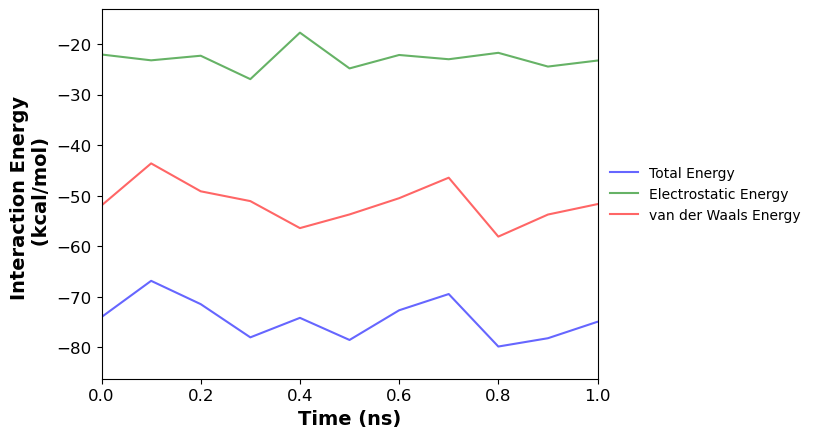

In [186]:
# プロット
plt.plot(time_array, lie_total, alpha=0.6, color='blue', linewidth=1.5, label="Total Energy")
plt.plot(time_array, lie_elec, alpha=0.6, color='green', linewidth=1.5, label="Electrostatic Energy")
plt.plot(time_array, lie_vdw, alpha=0.6, color='red', linewidth=1.5, label="van der Waals Energy")

plt.xlim(0, simulation_ns)
plt.xlabel("Time (ns)", fontsize=14, fontweight='bold')
plt.ylabel('Interaction Energy \n (kcal/mol)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig(lie_plot_path, dpi=600, bbox_inches='tight')

### RMSD

In [243]:
rmsd_csv_path = result_dir + "/rmsd.csv"
rmsd_plot_path = result_dir + '/plot_rmsd.png'

In [244]:
protein_resnames = {
    "ALA","GLY","VAL","LEU","ILE","MET","PHE","TYR","TRP",
    "SER","THR","CYS","ASN","GLN","ASP","GLU","LYS","ARG",
    "HIS","PRO"
}

protein_resids = []
for res in traj_load.topology.residues:
    if res.name in protein_resnames:
        protein_resids.append(res.index + 1)

first_resid = min(protein_resids)
last_resid  = max(protein_resids)
mask_sidechain = f":{first_resid}-{last_resid} & !@CA,C,O,N"

In [245]:
# 側鎖の情報を取得
top = pt.load_topology(system_prmtop_path)
residues = list(top.residues)  # generator → list に変換

# タンパク質残基範囲を決定
aa_resnames = {
    "ALA","GLY","VAL","LEU","ILE","MET","PHE","TYR","TRP",
    "SER","THR","CYS","ASN","GLN","ASP","GLU","LYS","ARG",
    "HIS","PRO"
}
residues = list(traj_load.topology.residues)
protein_resids = [res.index+1 for res in residues if res.name in aa_resnames]
first_resid = min(protein_resids)
last_resid  = max(protein_resids)

# 側鎖 = 全タンパク質 - backbone
sel_protein = pt.select_atoms(f":{first_resid}-{last_resid}", traj_load.topology)
sel_backbone = pt.select_atoms(f":{first_resid}-{last_resid} & @N,CA,C,O", traj_load.topology)
sel_sidechain = sorted(set(sel_protein) - set(sel_backbone))
mask_sidechain = "@" + ",".join(str(i+1) for i in sel_sidechain)
print("側鎖原子数:", len(sel_sidechain))

側鎖原子数: 3816


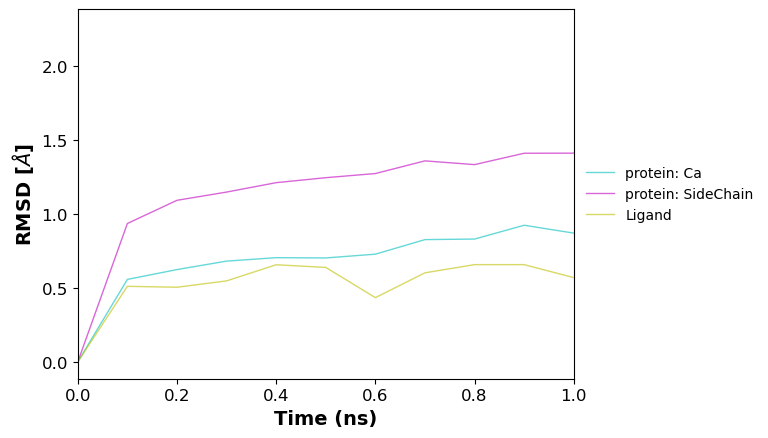

In [250]:
# RMSD算出
rmsd_ca = pt.rmsd(traj_load, ref=0, mask="@CA") # Ca原子
#rmsd_bb = pt.rmsd(traj_load, ref=0, mask="@CA,C,O,N")   # 主鎖
rmsd_sc = pt.rmsd(traj_load, ref=0, mask=mask_sidechain)   # 側鎖
rmsd_lig = pt.rmsd(traj_load, ref=0, mask=":UNK")    # リガンド

# 時間軸を作成
write_the_traj = 500000 / 5000  # n_steps / interval_steps
simulation_ns = 500000 * 2 * 10**(-6) # n_steps * interval_time / 10^-6
stride = 1
time = len(lie_total) * int(write_the_traj) / 1000  # ns
time_array = np.arange(0, time, int(write_the_traj)/1000) * int(stride)

# Plotting:
fig, ax = plt.subplots(1, 1)
ax.plot(time_array, rmsd_ca, alpha=0.6, color ="c", linewidth = 1.0, label="protein: Ca")
#ax.plot(time_array, rmsd_bb, alpha=0.6, color ="y", linewidth = 1.0, label="protein: BackBorn")
ax.plot(time_array, rmsd_sc, alpha=0.6, color ="m", linewidth = 1.0, label="protein: SideChain")
ax.plot(time_array, rmsd_lig, alpha=0.6, color ="y", linewidth = 1.0, label="Ligand")
plt.xlim(0, simulation_ns)
#plt.ylim(2, 6)
plt.xlabel("Time (ns)", fontsize = 14, fontweight = 'bold')
plt.ylabel("RMSD [$\AA$]", fontsize = 14, fontweight = 'bold')
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.savefig(rmsd_plot_path, dpi=600, bbox_inches='tight')
plt.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

raw_data_ca = pd.DataFrame(rmsd_ca, columns=["RMSD_protein_Ca"])
#raw_data_bb = pd.DataFrame(rmsd_bb)
raw_data_sc = pd.DataFrame(rmsd_sc, columns=["RMSD_protein_SideChain"])
raw_data_lig = pd.DataFrame(rmsd_lig, columns=["RMSD_protein_Ca"])
df_rmsd = pd.concat([raw_data_ca, raw_data_sc, raw_data_lig], axis=1)
df_rmsd.to_csv(rmsd_csv_path)

### PCA

In [254]:
pca_csv_path = result_dir + "/pca.csv"
pca_plot_path = result_dir + "/plot_pca.png"

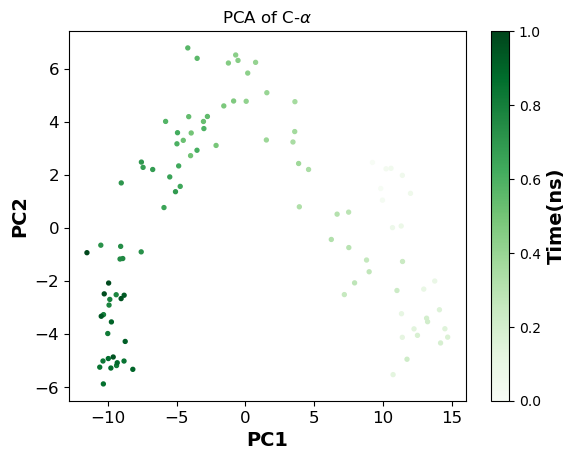

In [255]:
#主成分分析（PCA）
data = pt.pca(traj_load, fit=True, ref=0, mask='@CA', n_vecs=2)

# 時間軸を作成
write_the_traj = 500000 / 5000  # n_steps / interval_steps
simulation_ns = 500000 * 2 * 10**(-6) # n_steps * interval_time / 10^-6
stride = 1
time = len(lie_total) * int(write_the_traj) / 1000  # ns
time_array = np.arange(0, time, int(write_the_traj)/1000) * int(stride)
last_frame = len(time_array)

stride_ticks_f = (last_frame)/5
ticks_frame = np.arange(0,(len(time_array) + float(stride_ticks_f)), float(stride_ticks_f))
a = ticks_frame.astype(float)
a2 = a.tolist()
stride_ticks_t = (simulation_ns)/5
tick_time = np.arange(0,(float(simulation_ns) + float(stride_ticks_t)), float(stride_ticks_t))
b = tick_time.astype(float)

projection_data = data[0]
plt.title(r'PCA of C-$\alpha$')
PC1 = data[0][0] 
PC2 = data[0][1]

a = plt.scatter(PC1,PC2, c=range(int(last_frame)), cmap='Greens', marker='o',s=8, alpha=1)
plt.clim(0, last_frame)

plt.xlabel('PC1', fontsize = 14, fontweight = 'bold')
plt.ylabel('PC2', fontsize = 14, fontweight = 'bold')
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

cbar1 = plt.colorbar(a, orientation="vertical")
cbar1.set_label('Time(ns)', fontsize = 14, fontweight = 'bold')
cbar1.set_ticks(a2)
cbar1.set_ticklabels(b.round(decimals=3))

plt.savefig(pca_plot_path, dpi=600, bbox_inches='tight')
plt.show()

pc1 = pd.DataFrame(PC1, columns=["PC1"])
pc2 = pd.DataFrame(PC2, columns=["PC2"])
df_pc = pd.concat([pc1, pc2], axis=1)
df_pc.to_csv(pca_csv_path)

### Pearson's Cross Correlation

In [257]:
from pytraj import matrix

In [259]:
cc_csv_path = result_dir + "/cc.csv"
cc_plot_path = result_dir + "/plot_cc.png"

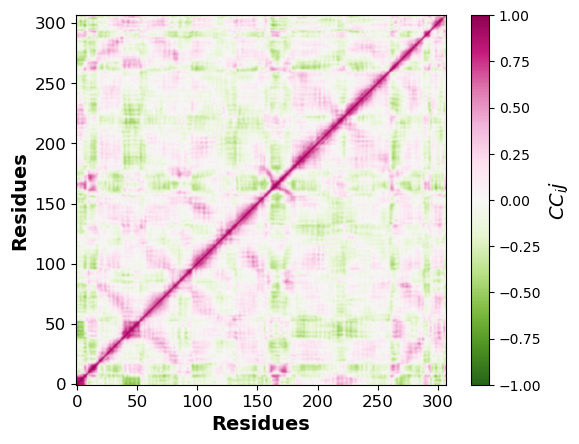

In [260]:
traj_align = pt.align(traj_load, mask="@CA", ref=0)

mat_cc = matrix.correl(traj_align, "@CA")

ax = plt.imshow(mat_cc, cmap = "PiYG_r", interpolation = "bicubic", vmin = -1, vmax = 1, origin="lower")

plt.xlabel("Residues", fontsize = 14, fontweight = "bold")
plt.ylabel("Residues", fontsize = 14, fontweight = "bold")
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
cbar1 = plt.colorbar()
cbar1.set_label("$CC_ij$", fontsize = 14, fontweight = "bold")

plt.savefig(cc_plot_path, dpi=600, bbox_inches='tight')

raw_data = pd.DataFrame(mat_cc)
raw_data.to_csv(cc_csv_path)